Imports and Data Loading

In [1]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

X_train = np.load('../data/processed/X_train.npy')
y_train = np.load('../data/processed/y_train.npy')
X_val = np.load('../data/processed/X_val.npy')
y_val = np.load('../data/processed/y_val.npy')

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

# Calculate number of input features based on preprocessing
num_features = X_train.shape[1]

X_train shape: (30693, 9)
y_train shape: (30693, 1)
X_val shape: (6577, 9)
y_val shape: (6577, 1)


MLP ANN Architecture

In [2]:
model = keras.Sequential([
# Input Layer
    keras.layers.Dense(16, activation='relu', input_shape=(num_features,)),
    keras.layers.Dropout(0.2),

# Hidden Layer 2
    keras.layers.Dense(12, activation='relu'),
    keras.layers.Dropout(0.2),

# Hidden Layer 3
    keras.layers.Dense(8, activation='relu'),

# Output Layer (1 continuous output: kWh)
    keras.layers.Dense(1, activation='linear')
])

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

c:\Users\User\OneDrive\Documents\Codes\2nd Sem Python Codes\Intelligent Systems\renewable_energy_ann\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           204 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477 (1.86 KB)

 Trainable params: 477 (1.86 KB)

 Non-trainable params: 0 (0.00 B)

Configuring Callbacks

In [3]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=15, 
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='../models/best_model_iloilo.h5',
        monitor='val_loss', 
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=7, 
        min_lr=1e-6,
        verbose=1
    )
]

Training the Model

In [4]:
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
945/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0488 - mae: 0.1539
Epoch 1: val_loss improved from None to 0.01450, saving model to ../models/best_model_iloilo.h5



Epoch 1: finished saving model to ../models/best_model_iloilo.h5
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0304 - mae: 0.1183 - val_loss: 0.0145 - val_mae: 0.0765 - learning_rate: 0.0010
Epoch 2/200
936/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0171 - mae: 0.0871
Epoch 2: val_loss improved from 0.01450 to 0.01389, saving model to ../models/best_model_iloilo.h5



Epoch 2: finished saving model to ../models/best_model_iloilo.h5
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0160 - mae: 0.0835 - val_loss: 0.0139 - val_mae: 0.0717 - learning_rate: 0.0010
Epoch 3/200
918/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0141 - mae: 0.0771
Epoch 3: val_loss improved from 0.01389 to 0.01277, saving model to ../models/best_model_iloilo.h5



Epoch 3: finished saving model to ../models/best_model_iloilo.h5
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0139 - mae: 0.0762 - val_loss: 0.0128 - val_mae: 0.0691 - learning_rate: 0.0010
Epoch 4/200
921/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0129 - mae: 0.0733
Epoch 4: val_loss improved from 0.01277 to 0.01154, saving model to ../models/best_model_iloilo.h5



Epoch 4: finished saving model to ../models/best_model_iloilo.h5
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0129 - mae: 0.0727 - val_loss: 0.0115 - val_mae: 0.0670 - learning_rate: 0.0010
Epoch 5/200
928/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0123 - mae: 0.0710
Epoch 5: val_loss did not improve from 0.01154
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0122 - mae: 0.0701 - val_loss: 0.0129 - val_mae: 0.0669 - learning_rate: 0.0010
Epoch 6/200
950/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0120 - mae: 0.0687
Epoch 6: val_loss did not improve from 0.01154
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0118 - mae: 0.0680 - val_loss: 0.0139 - val_mae: 0.0710 - learning_rate: 0.0010
Epoch 7/200
930/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0116 - mae: 0.0674
Epoch 7: val_loss did not improve from 0.01154
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0114 - mae: 0.0664 - val_loss: 0.0121 - val_mae: 0.0651 - learning_rate: 0.0010
Epoch 8/200
936/960 ━━━

...


Epoch 15: finished saving model to ../models/best_model_iloilo.h5
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0093 - mae: 0.0576 - val_loss: 0.0108 - val_mae: 0.0614 - learning_rate: 0.0010
Epoch 16/200
957/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0092 - mae: 0.0569
Epoch 16: val_loss improved from 0.01077 to 0.01054, saving model to ../models/best_model_iloilo.h5



Epoch 16: finished saving model to ../models/best_model_iloilo.h5
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0092 - mae: 0.0567 - val_loss: 0.0105 - val_mae: 0.0606 - learning_rate: 0.0010
Epoch 17/200
940/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0092 - mae: 0.0562
Epoch 17: val_loss did not improve from 0.01054
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0091 - mae: 0.0562 - val_loss: 0.0111 - val_mae: 0.0621 - learning_rate: 0.0010
Epoch 18/200
948/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0089 - mae: 0.0553
Epoch 18: val_loss improved from 0.01054 to 0.01007, saving model to ../models/best_model_iloilo.h5



Epoch 18: finished saving model to ../models/best_model_iloilo.h5
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0089 - mae: 0.0552 - val_loss: 0.0101 - val_mae: 0.0610 - learning_rate: 0.0010
Epoch 19/200
918/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0088 - mae: 0.0556
Epoch 19: val_loss did not improve from 0.01007
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0087 - mae: 0.0547 - val_loss: 0.0104 - val_mae: 0.0598 - learning_rate: 0.0010
Epoch 20/200
911/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1000us/step - loss: 0.0085 - mae: 0.0535
Epoch 20: val_loss did not improve from 0.01007
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0087 - mae: 0.0540 - val_loss: 0.0106 - val_mae: 0.0610 - learning_rate: 0.0010
Epoch 21/200
954/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0085 - mae: 0.0536
Epoch 21: val_loss did not improve from 0.01007
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0085 - mae: 0.0533 - val_loss: 0.0116 - val_mae: 0.0633 - learning_rate: 0.0010
Epoch 22/200



Epoch 26: finished saving model to ../models/best_model_iloilo.h5
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0079 - mae: 0.0508 - val_loss: 0.0097 - val_mae: 0.0586 - learning_rate: 5.0000e-04
Epoch 27/200
938/960 ━━━━━━━━━━━━━━━━━━━━ 0s 972us/step - loss: 0.0080 - mae: 0.0513
Epoch 27: val_loss did not improve from 0.00971
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0080 - mae: 0.0514 - val_loss: 0.0102 - val_mae: 0.0601 - learning_rate: 5.0000e-04
Epoch 28/200
947/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0081 - mae: 0.0515
Epoch 28: val_loss did not improve from 0.00971
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0080 - mae: 0.0515 - val_loss: 0.0112 - val_mae: 0.0624 - learning_rate: 5.0000e-04
Epoch 29/200
946/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0077 - mae: 0.0504
Epoch 29: val_loss did not improve from 0.00971
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0078 - mae: 0.0507 - val_loss: 0.0108 - val_mae: 0.0612 - learning_rate: 5.0000e-0


Epoch 35: finished saving model to ../models/best_model_iloilo.h5
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0077 - mae: 0.0498 - val_loss: 0.0096 - val_mae: 0.0585 - learning_rate: 2.5000e-04
Epoch 36/200
939/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0077 - mae: 0.0494
Epoch 36: val_loss did not improve from 0.00960
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0077 - mae: 0.0495 - val_loss: 0.0105 - val_mae: 0.0604 - learning_rate: 2.5000e-04
Epoch 37/200
952/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0079 - mae: 0.0510
Epoch 37: val_loss did not improve from 0.00960
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0077 - mae: 0.0501 - val_loss: 0.0102 - val_mae: 0.0602 - learning_rate: 2.5000e-04
Epoch 38/200
928/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0076 - mae: 0.0502
Epoch 38: val_loss did not improve from 0.00960
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0077 - mae: 0.0500 - val_loss: 0.0101 - val_mae: 0.0588 - learning_rate: 2.5000e-04


In [7]:
best_epoch = np.argmin(history.history['val_loss'])

best_val_loss = history.history['val_loss'][best_epoch]
best_val_mae = history.history['val_mae'][best_epoch]
best_train_loss = history.history['loss'][best_epoch]
best_train_mae = history.history['mae'][best_epoch]

print(f"Best Epoch: {best_epoch + 1}")
print(f"Training Loss (MSE): {best_train_loss:.5f}")
print(f"Training MAE:        {best_train_mae:.5f}")
print(f"Validation Loss (MSE): {best_val_loss:.5f}")
print(f"Validation MAE:        {best_val_mae:.5f}")

Best Epoch: 35
Training Loss (MSE): 0.00772
Training MAE:        0.04976
Validation Loss (MSE): 0.00960
Validation MAE:        0.05845


Training History Plot

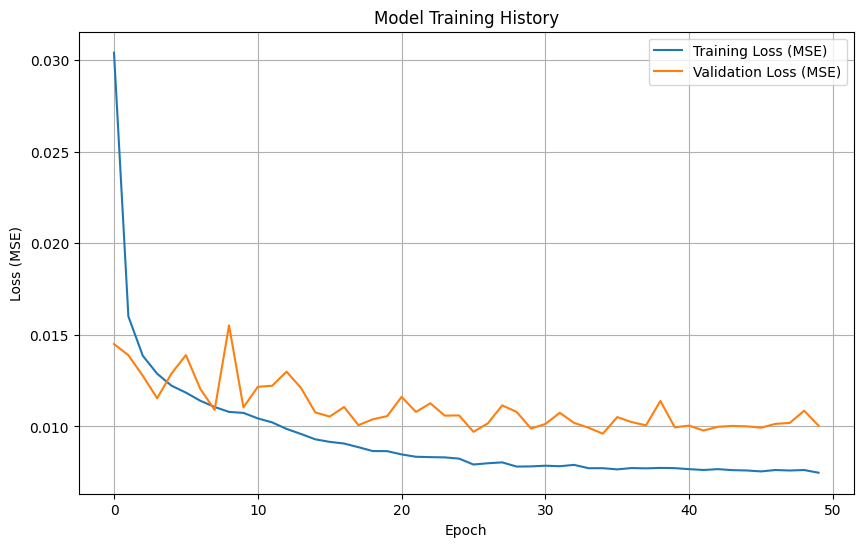

In [5]:
os.makedirs('../figures', exist_ok=True)
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Model Training History')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.savefig('../figures/training_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()